# What are the most demanded skills for the top 3 most popular data roles?

### Methodology
- Clean-up skill column
- Calculate skill count based on job_title_short
- Calculate skill percentage
- Plot final findings

In [38]:
# Import Libraries
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

# Loading the dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [63]:
# %%
df_DE = df[df['job_country'] == 'Germany']

df_skills = df_DE.explode('job_skills')

# %%
df_skills_count = (
    df_skills
    .groupby(['job_skills', 'job_title_short'])
    .size()
    .reset_index(name='skill_count')
    .sort_values(by='skill_count', ascending=False)
)

# %%
df_job_title_count = (
    df_DE['job_title_short']
    .value_counts()
    .reset_index(name='jobs_total')
)

In [64]:
job_titles = (
    df_job_title_count
    .sort_values(by='jobs_total', ascending=False)
    ['job_title_short']
    .head(3)
    .tolist()
)

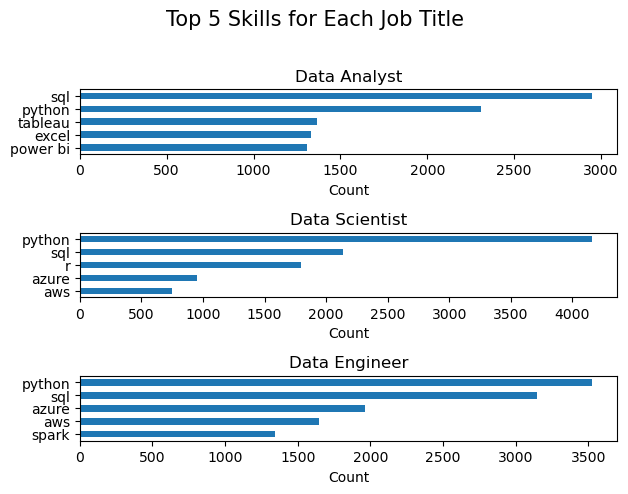

In [ ]:
fig, ax = plt.subplots(len(job_titles), 1, figsize=(6, 8))

for i, job_title in enumerate(job_titles):
    df_plot = (
        df_skills_count[df_skills_count['job_title_short'] == job_title]
        .sort_values(by='skill_count', ascending=False)
        .head(5)
    )

    df_plot.plot(x='job_skills', y='skill_count', kind='barh', ax=ax[i], title=job_title)

    ax[i].invert_yaxis()
    ax[i].set_xlabel('Count')
    ax[i].set_ylabel('')
    ax[i].legend().remove()

fig.suptitle('Top 5 Skills for Each Job Title', y=1.02, fontsize=15)
fig.tight_layout()
plt.show()

In [68]:
# Merge for percentage calculation
df_skill_per = pd.merge(df_skills_count, df_job_title_count, how='left', on='job_title_short')

df_skill_per['skill_percentage'] = (df_skill_per['skill_count'] / df_skill_per['jobs_total']) * 100

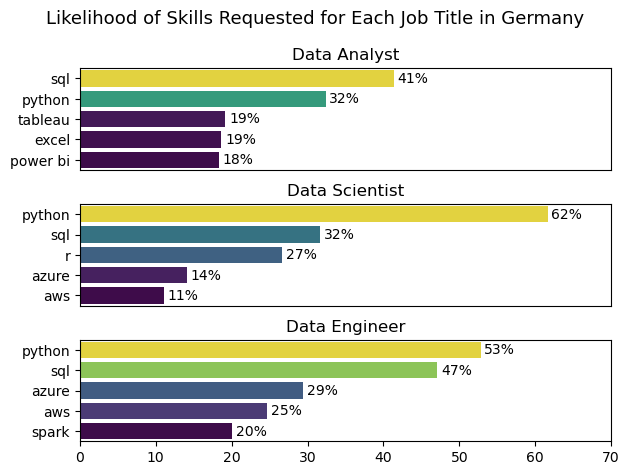

In [77]:
# %%
fig, ax = plt.subplots(len(job_titles), 1)

for i, job_title in enumerate(job_titles):
    df_plot = (
        df_skill_per[df_skill_per['job_title_short'] == job_title]
        .sort_values(by='skill_percentage', ascending=False)
        .head(5)
    )

    sns.barplot(
        x='skill_percentage',
        y='job_skills',
        data=df_plot,
        ax=ax[i],
        hue='skill_percentage',
        palette='viridis',
        legend=False
    )

    ax[i].set_title(job_title)
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')
    ax[i].set_xlim(0, 70)

    for n, v in enumerate(df_plot['skill_percentage']):
        ax[i].text(v + 0.5, n, f"{v:.0f}%", color='black', va='center')

    if i != len(job_titles) - 1:
        ax[i].set_xticks([])

fig.suptitle(
    'Likelihood of Skills Requested for Each Job Title in Germany',
    fontsize=13
)

fig.tight_layout(h_pad=1.0)
plt.show()